In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
df = pd.read_csv('Ratio.csv')
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.843663
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.783431
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.777522
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.825769
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.889904


<Axes: >

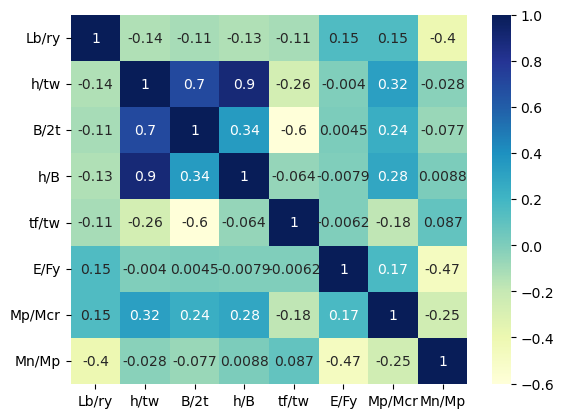

In [3]:
sns.heatmap(df.corr(numeric_only=True), cmap="YlGnBu", annot=True)

In [4]:
df.describe()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
count,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000
mean,97.366596,34.963695,5.634730,1.853852,1.653545,248.937214,1.624280,0.726006
std,37.083167,14.070018,1.363515,0.583968,0.116217,40.796326,0.948242,0.192763
min,29.629630,10.100775,3.115942,0.885256,1.380000,208.279468,0.232590,0.203974
25%,68.441065,20.685393,4.491525,1.588288,1.597315,208.279468,0.905141,0.605143
50%,93.655589,36.729167,5.434783,1.911429,1.640351,208.279468,1.416495,0.747639
75%,120.786517,45.524476,6.826087,2.216407,1.730496,289.779767,2.146375,0.905529
max,247.734139,61.420000,7.971014,2.791818,1.903614,289.779767,5.694176,1.009362


(0.0, 1.0)

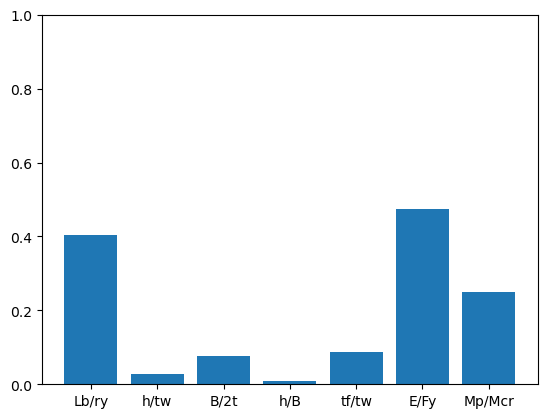

In [5]:
C = df.corr(numeric_only=True)['Mn/Mp'][:-1]
plt.bar(C.index, np.abs(C.values))
plt.ylim([0, 1])

In [6]:
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.1, random_state=100)

In [8]:
def evaluate_pipeline(estimator, grid_params, search_method=GridSearchCV):
    cv = search_method(estimator, grid_params)
    cv.fit(X_train, y_train)

    pipeline = cv.best_estimator_
    
    pipeline_test_prd = pipeline.predict(X_test)
    pipeline_test_mse = mean_squared_error(pipeline_test_prd, y_test)
    pipeline_test_mae = mean_absolute_error(pipeline_test_prd, y_test)
    pipeline_test_r2_score = r2_score(pipeline_test_prd, y_test)
    
    pipeline_full_prd = pipeline.predict(X_full)
    pipeline_full_mse = mean_squared_error(pipeline_full_prd, y_full)
    pipeline_full_mae = mean_absolute_error(pipeline_full_prd, y_full)
    pipeline_full_r2_score = r2_score(pipeline_full_prd, y_full)
    
    print(f"Best params  :  {cv.best_params_}")
    print(f"Test MSE     :  {pipeline_test_mse}")
    print(f"Test MAE     :  {pipeline_test_mae}")
    print(f"Test R2      :  {pipeline_test_r2_score}")
    print(f"Full MSE     :  {pipeline_full_mse}")
    print(f"Full MSE     :  {pipeline_full_mae}")
    print(f"Full R2      :  {pipeline_full_r2_score}")

    return pipeline, pd.DataFrame(cv.cv_results_)

In [9]:
rf_params = {
    'criterion' : ['squared_error', 'friedman_mse', 'poisson'],
    'n_estimators' : [150, 200, 250, 300],
}

_ = evaluate_pipeline(RandomForestRegressor(random_state=42), rf_params)

Best params  :  {'criterion': 'poisson', 'n_estimators': 150}
Test MSE     :  0.0039417884753931865
Test MAE     :  0.04033925587051848
Test R2      :  0.910173128456926
Full MSE     :  0.0007337927701785185
Full MSE     :  0.014407832191730873
Full R2      :  0.9785337877712665


In [10]:
gb_params = {
    'criterion' : ['squared_error', 'friedman_mse'],
    'n_estimators' : [150, 200, 250, 300],
}

_ = evaluate_pipeline(GradientBoostingRegressor(random_state=42), gb_params)

Best params  :  {'criterion': 'squared_error', 'n_estimators': 150}
Test MSE     :  0.005820604367044598
Test MAE     :  0.05288127582805038
Test R2      :  0.8536349982958803
Full MSE     :  0.0013425003132873342
Full MSE     :  0.024347079528137656
Full R2      :  0.9593998166902156


In [14]:
from sklearn.svm import SVR
from scipy.stats import loguniform, uniform

svr_params = {
    'C': loguniform(1e-3, 1e3),
    'epsilon': uniform(0.01, 0.1),
    'gamma': loguniform(1e-3, 1e3)
}

_ = evaluate_pipeline(SVR(), svr_params, RandomizedSearchCV)

Best params  :  {'C': np.float64(68.26153874827986), 'epsilon': np.float64(0.02159504187920041), 'gamma': np.float64(0.0013689230798606484)}
Test MSE     :  0.007705891551133817
Test MAE     :  0.048430588077947166
Test R2      :  0.8214405737680273
Full MSE     :  0.0017788874907372
Full MSE     :  0.02219038956562589
Full R2      :  0.9500822466183928


Best params  :  {'mlp__activation': 'relu', 'mlp__hidden_layer_sizes': (32, 32, 32, 32)}
Test MSE     :  0.0036722442691033566
Test MAE     :  0.03906848987366366
Test R2      :  0.9163939195582546
Full MSE     :  0.0011241715563297834
Full MSE     :  0.019209341167817133
Full R2      :  0.9680391657648946


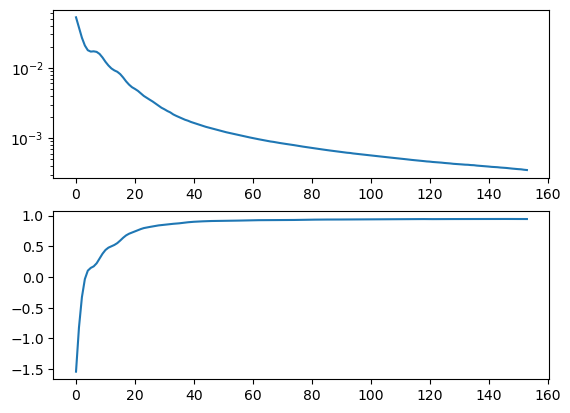

In [18]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

nn_params = {
    'mlp__hidden_layer_sizes' : [(16, 16, 16, 16), (32, 32, 32, 32), (64, 64)],
    'mlp__activation' : ['relu', 'tanh'],
}

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=500))
])

nn_pipeline, _ = evaluate_pipeline(nn_pipeline, nn_params)

plt.subplot(2, 1, 1)
plt.semilogy(nn_pipeline['mlp'].loss_curve_)
plt.subplot(2, 1, 2)
plt.plot(nn_pipeline['mlp'].validation_scores_)
plt.show()